# Baseline of model, introducing of general metrics

## Introduction to metrics, baseline models

Для оценки качества моделей и бейзлайна, буду применять стандартные метрики качества такие как: MAE, RMSE, MAPE, SMAPE

$MAE = \frac{1}{n}\sum_{t=1}^{n}|y_t - \hat{y}_t|$

$RMSE = \sqrt{\frac{1}{n}\sum_{t=1}^n(y_t - \hat{y}_t)^2}$

$MAPE = \frac{100}{n}\sum_{t=1}^{n}|\frac{y_t - \hat{y}_t}{y_t}|$

$SMAPE = \frac{100}{n}\sum_{t=1}^{n}|\frac{2(y_t - \hat{y}_t)|}{|y_t| + |\hat{y}_t|}$

MAE характеризует среднюю величину ошибки, RMSE сильнее штрафует большие ошибки, а MAPE позволяет интерпретировать точность прогноза в процентном выражении.

В качестве базовых моделей прогнозирования (baseline) используются несколько классических методов прогнозирования временных рядов:

**Наивный прогноз (Naive forecast)**

Предполагается, что значение временного ряда в следующий момент времени равно последнему наблюдаемому значению:

$\hat{y}_{t+1} = y_t$

**Seasonal Naive**

$\hat{y}_{t+h} = y_{t+h-s} $

**Экспоненциальное сглаживание**

Метод простого экспоненциального сглаживания позволяет учитывать влияние предыдущих наблюдений с экспоненциально убывающими весами.
Данный метод реализуется в рамках модели Exponential Smoothing.

**Метод Хольта–Уинтерса**

Для временных рядов, содержащих тренд и сезонность, используется тройное экспоненциальное сглаживание — модель Holt-Winters method, которая учитывает:
- уровень ряда
- тренд
- сезонную компоненту.

В качестве горизонта будем прогнозировать на: 1 месяц, квартал, полугодие, год

Проведем эксперименты отдельно по каждой группе (product, market), product (aggregated by store), market (aggregated by products), total (aggregated by date) 

## Prepare

In [1]:
from sklearn.metrics import mean_absolute_percentage_error as mape, mean_absolute_error as mae, root_mean_squared_error as rmse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

def smape(y: np.array, y_forecast: np.array) -> float:

    if len(y) != len(y_forecast):
        raise ValueError("y and y_forecast must have the same length")

    denominator = (np.abs(y) + np.abs(y_forecast)) / 2

    diff = np.abs(y - y_forecast) / denominator

    diff[denominator == 0] = 0

    return np.mean(diff) * 100

def evaluate(y, y_hat):

    return {
        "MAE": mae(y, y_hat),
        "RMSE": rmse(y, y_hat),
        "MAPE": mape(y, y_hat),
        "SMAPE": smape(y, y_hat)
    }

In [11]:
data = pd.read_csv('../data/data_4_forecast.csv')
data['PER_SDESC'] = pd.to_datetime(data['PER_SDESC'])
data['PER_SDESC'].dt.to_period('M').dt.to_timestamp()
data.head(10)

,Row Labels,MKT_SDESC,PER_SDESC,MT_Volume KG,NT_CWD,NT_Avg Line,NT_Price per kg,NT_Universe,MT_Universe percent,Frequency,...,sales_rolling1_std,sales_rolling3_mean,sales_rolling3_std,sales_rolling6_mean,sales_rolling6_std,sales_rolling12_mean,sales_rolling12_std,NT_CWD_clean,differentiation,NT_CWD_diff
0,BAGS,Discounters,2019-01-01,1458414.5,3175.94,31.759400,361.647156,26047.36129,0.126383,1.779020,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3175.94,1,NaN
1,BAGS,Discounters,2019-02-01,1599316.0,3151.74,31.517400,357.873791,26385.74648,0.127194,1.779020,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3151.74,1,-24.20
2,BAGS,Discounters,2019-03-01,1505515.5,3155.40,31.554000,385.256139,26475.00379,0.128160,1.779020,...,NaN,3161.026667,13.044330,NaN,NaN,NaN,NaN,3155.40,1,3.66
3,BAGS,Discounters,2019-04-01,1565605.8,3414.86,34.152015,393.144379,26895.73306,0.129438,1.792873,...,NaN,3240.666667,150.866951,NaN,NaN,NaN,NaN,3414.86,1,259.46
4,BAGS,Discounters,2019-05-01,1508979.0,3394.44,33.944400,404.401652,27153.48617,0.130361,1.792873,...,NaN,3321.566667,144.266299,NaN,NaN,NaN,NaN,3394.44,1,-20.42
5,BAGS,Discounters,2019-06-01,1271805.5,3282.95,32.829500,401.501645,27337.00409,0.135128,1.792873,...,NaN,3364.083333,71.001461,3262.555000,120.225404,NaN,NaN,3282.95,1,-111.49
6,BAGS,Discounters,2019-07-01,1415931.8,3222.57,32.225700,393.357929,27709.80939,0.136254,1.746947,...,NaN,3299.986667,87.192375,3270.326667,114.895594,NaN,NaN,3222.57,1,-60.38
7,BAGS,Discounters,2019-08-01,1504473.5,3075.20,30.752000,388.692735,27994.67277,0.137611,1.746947,...,NaN,3193.573333,106.867304,3257.570000,133.446777,NaN,NaN,3075.20,1,-147.37
8,BAGS,Discounters,2019-09-01,1506278.6,2887.48,28.874800,383.797133,28145.16792,0.138331,1.746947,...,NaN,3061.750000,167.949409,3212.916667,201.794246,NaN,NaN,2887.48,1,-187.72
9,BAGS,Discounters,2019-10-01,1566526.6,2730.77,27.307700,404.944799,28466.71358,0.143768,1.760222,...,NaN,2897.816667,172.447503,3098.901667,251.909653,NaN,NaN,2730.77,1,-156.71


In [12]:
# выбираем нужные колонки
import json
df_selected = data[['Row Labels', 'MKT_SDESC', 'PER_SDESC', 'NT_CWD']].copy()

# переименовываем под нужный формат
df_selected = df_selected.rename(columns={
    'Row Labels': 'product',
    'MKT_SDESC': 'market',
    'PER_SDESC': 'date',
    'NT_CWD': 'value'
})

df_selected['date'] = pd.to_datetime(df_selected['date']).dt.strftime('%Y-%m-%d')

# собираем список словарей
data_out = df_selected.to_dict(orient='records')

# финальный JSON
result = {
    "data": data_out
}

# сохранить в файл
with open('output.json', 'w', encoding='utf-8') as f:
    json.dump(result, f, ensure_ascii=False, indent=2)

In [6]:
def ts_split(series, horizon):

    train = series.iloc[:-horizon]
    test = series.iloc[-horizon:]
    return train, test

In [7]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

def naive_forecast(train, horizon):

    last_value = train.iloc[-1]
    forecast = np.repeat(last_value, horizon)

    return forecast

def seasonal_naive(train, horizon, season_length=12):

    forecast = train.iloc[-season_length:][:horizon]

    return forecast.values


def ses_forecast(train, horizon):

    model = SimpleExpSmoothing(train).fit()

    forecast = model.forecast(horizon)

    return forecast.values


def hw_forecast(train, horizon):

    model = ExponentialSmoothing(
        train,
        trend="add",
        seasonal="add",
        seasonal_periods=12
    ).fit()

    forecast = model.forecast(horizon)

    return forecast.values

## Total Sale

In [13]:
horizons = [1,3,6,12]

splits = {}

df = data.groupby('PER_SDESC').agg({'NT_CWD':'sum'})
df.sort_values('PER_SDESC')
for h in horizons:

    train, test = ts_split(df, h)

    key = h

    splits[key] = {
        "train": train,
        "test": test
    }

In [14]:
results = []

for key in splits.keys():

    train_df = splits[key]['train']
    test_df = splits[key]['test']

    h = key
    
    y_train = train_df["NT_CWD"].asfreq('MS')
    
    y_test = test_df["NT_CWD"].asfreq('MS')

    models = {
        "naive": naive_forecast,
        "seasonal_naive": seasonal_naive,
        "ses": ses_forecast,
        "holt_winters": hw_forecast
    }

    for model_name, model in models.items():

        forecast = model(y_train, h)

        metrics = evaluate(y_test.values, forecast)

        metrics["horizon"] = h
        metrics["model"] = model_name
        results.append(metrics)

results = pd.DataFrame(results)

In [15]:
summary_total = (
    results
    .groupby(['model', 'horizon'])
    .agg({'MAE':'mean', 'RMSE':'mean', 'MAPE':'mean', 'SMAPE':'mean'})
    .reset_index()
)
summary_total

,model,horizon,MAE,RMSE,MAPE,SMAPE
0,holt_winters,1,791.804434,791.804434,0.004487,0.447724
1,holt_winters,3,5564.606277,5591.334390,0.031075,3.059677
2,holt_winters,6,10581.079897,11324.345505,0.058179,5.627416
3,holt_winters,12,5152.692359,6003.555360,0.027838,2.787744
4,naive,1,352.230000,352.230000,0.001996,0.199814
5,naive,3,8857.336667,9570.261270,0.049952,4.852871
6,naive,6,15023.673333,16389.076073,0.082896,7.900135
7,naive,12,5849.863333,7558.052279,0.031216,3.110659
8,seasonal_naive,1,11962.680000,11962.680000,0.067794,6.557172
9,seasonal_naive,3,13244.790000,13285.223982,0.073993,7.134351


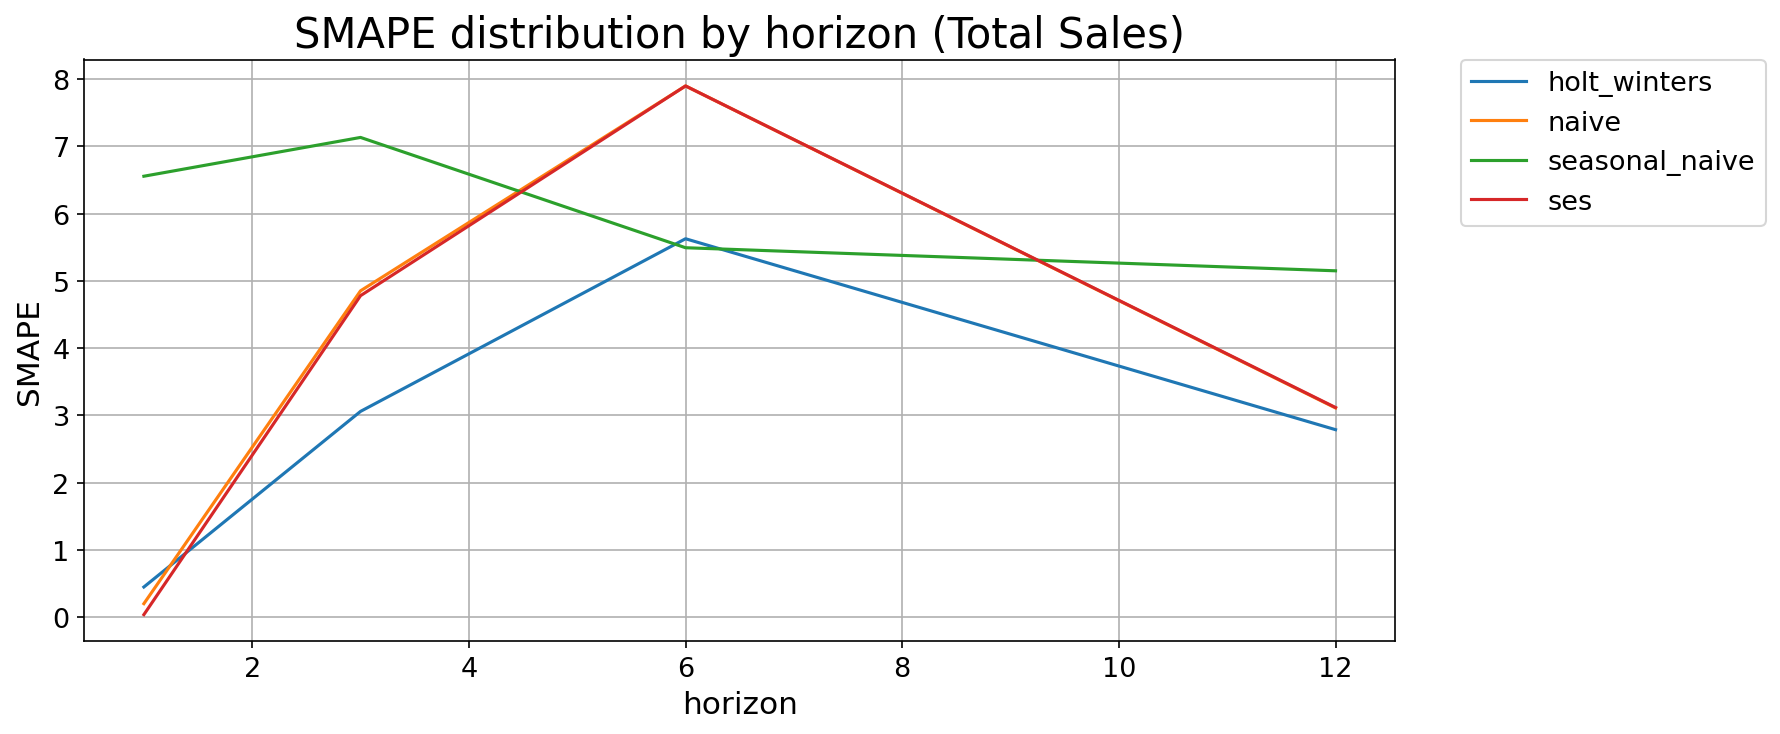

In [55]:
plt.style.use('default')
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.titlesize": 20,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.dpi": 150
})
plt.figure(figsize=(12,5))
sns.lineplot(summary_total, x = 'horizon', y = 'SMAPE', hue='model')
title = 'SMAPE distribution by horizon (Total Sales)'
plt.title(title)
plt.grid()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.savefig('../plots/'+title+'.png')
plt.show()

## Products

In [31]:
horizons = [1,3,6,12]

splits = {}

for product, df in data.groupby('Row Labels'):
    df = df.groupby('PER_SDESC').agg({'NT_CWD':'sum'})
    df = df.sort_values('PER_SDESC')
    for h in horizons:

        train, test = ts_split(df, h)

        key = (product, h)

        splits[key] = {
        "train": train,
        "test": test
        }

In [32]:
results = []

for key in splits.keys():

    train_df = splits[key]['train']
    test_df = splits[key]['test']

    product, h = key

    y_train = train_df["NT_CWD"].asfreq('MS')
    
    y_test = test_df["NT_CWD"].asfreq('MS')

    models = {
        "naive": naive_forecast,
        "seasonal_naive": seasonal_naive,
        "ses": ses_forecast,
        "holt_winters": hw_forecast
    }

    for model_name, model in models.items():

        forecast = model(y_train, h)

        metrics = evaluate(y_test.values, forecast)

        metrics["product"] = product
        # metrics["market"] = market
        metrics["horizon"] = h
        metrics["model"] = model_name

        results.append(metrics)
results = pd.DataFrame(results)

In [33]:
summary_products = (
    results
    .groupby(['model', 'horizon'])
    .agg({'MAE':'mean', 'RMSE':'mean', 'MAPE':'mean', 'SMAPE':'mean'})
    .reset_index()
)
summary_products

,model,horizon,MAE,RMSE,MAPE,SMAPE
0,holt_winters,1,389.531970,389.531970,0.034053,3.457650
1,holt_winters,3,834.429305,887.104079,0.058670,5.624555
2,holt_winters,6,890.929918,1026.699050,0.065927,6.202995
3,holt_winters,12,921.617329,1127.583837,0.060355,6.138580
4,naive,1,342.382727,342.382727,0.035310,3.664355
5,naive,3,921.719697,1014.799527,0.055760,5.233083
6,naive,6,1398.668485,1592.304234,0.100878,9.114867
7,naive,12,875.636061,1144.275350,0.057942,5.910897
8,seasonal_naive,1,1263.647273,1263.647273,0.075776,7.306297
9,seasonal_naive,3,1294.856061,1345.284711,0.076944,7.241394


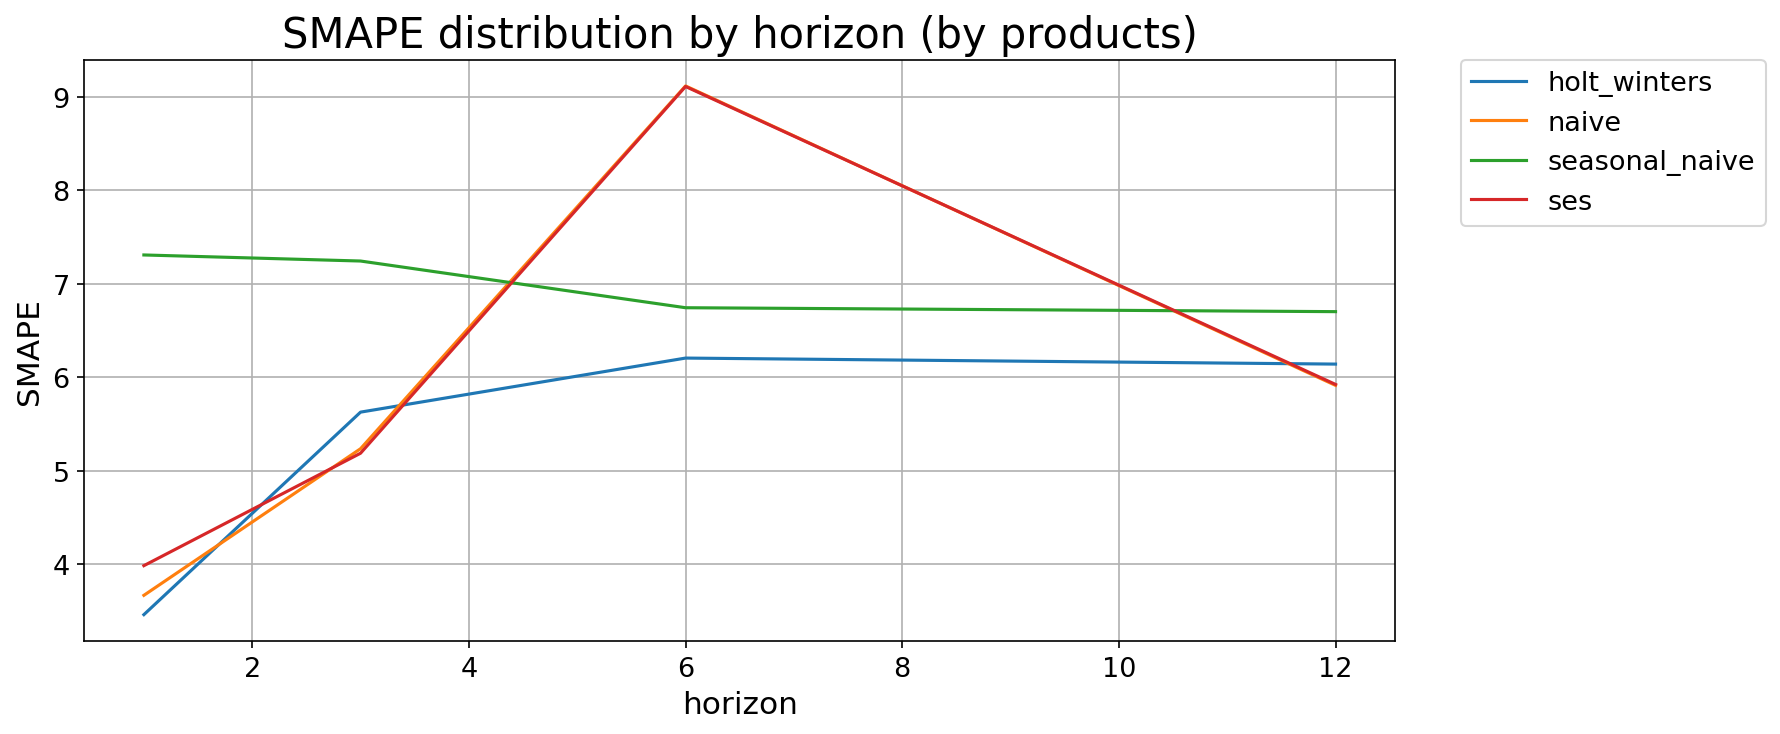

In [51]:
plt.figure(figsize=(12,5))
sns.lineplot(summary_products, x = 'horizon', y = 'SMAPE', hue='model')
title = 'SMAPE distribution by horizon (by products)'
plt.title(title)
plt.grid()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.savefig('../plots/'+title+'.png')
plt.show()

## Stores

In [41]:
horizons = [1,3,6,12]

splits = {}

for product, df in data.groupby('MKT_SDESC'):
    df = df.groupby('PER_SDESC').agg({'NT_CWD':'sum'})
    df = df.sort_values('PER_SDESC')
    for h in horizons:

        train, test = ts_split(df, h)

        key = (product, h)

        splits[key] = {
        "train": train,
        "test": test
        }

In [42]:
results = []

for key in splits.keys():

    train_df = splits[key]['train']
    test_df = splits[key]['test']

    market, h = key
    y_train = train_df["NT_CWD"].asfreq('MS')
    
    y_test = test_df["NT_CWD"].asfreq('MS')
    
    models = {
        "naive": naive_forecast,
        "seasonal_naive": seasonal_naive,
        "ses": ses_forecast,
        "holt_winters": hw_forecast
    }

    for model_name, model in models.items():

        forecast = model(y_train, h)

        metrics = evaluate(y_test.values, forecast)

        # metrics["product"] = product
        metrics["market"] = market
        metrics["horizon"] = h
        metrics["model"] = model_name

        results.append(metrics)

results = pd.DataFrame(results)

In [38]:
summary_stores = (
    results
    .groupby(['model', 'horizon'])
    .agg({'MAE':'mean', 'RMSE':'mean', 'MAPE':'mean', 'SMAPE':'mean'})
    .reset_index()
)
summary_stores

,model,horizon,MAE,RMSE,MAPE,SMAPE
0,holt_winters,1,1254.936473,1254.936473,0.030223,2.979278
1,holt_winters,3,1496.401715,1688.402577,0.027752,2.717299
2,holt_winters,6,2668.030031,2938.073517,0.052696,5.093388
3,holt_winters,12,1889.956559,2327.035063,0.036661,3.688747
4,naive,1,896.987500,896.987500,0.018665,1.858146
5,naive,3,2401.004167,2537.970722,0.044861,4.359679
6,naive,6,3812.508333,4183.995047,0.071442,6.813989
7,naive,12,1652.420000,2095.504995,0.032285,3.215888
8,seasonal_naive,1,2990.670000,2990.670000,0.067448,6.522151
9,seasonal_naive,3,3311.197500,3398.727686,0.063067,6.080616


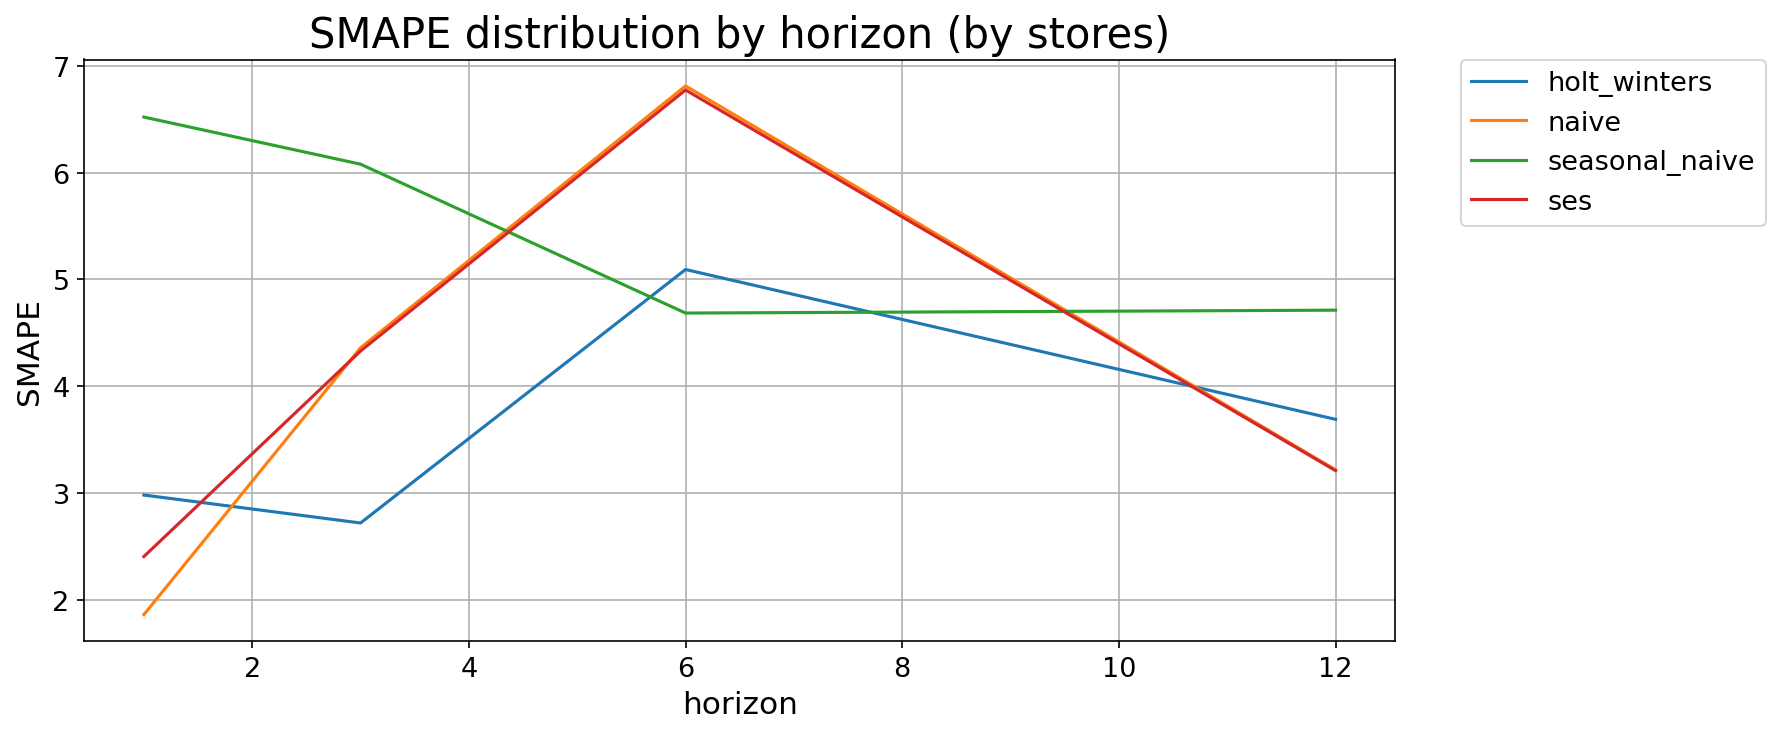

In [52]:
plt.figure(figsize=(12,5))
sns.lineplot(summary_stores, x = 'horizon', y = 'SMAPE', hue='model')
title = 'SMAPE distribution by horizon (by stores)'
plt.title(title)
plt.grid()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.savefig('../plots/'+title+'.png')
plt.show()

## Product + Market

In [44]:
horizons = [1,3,6,12]

splits = {}

for (product, market), df in data.groupby(['Row Labels','MKT_SDESC']):

    df = df.groupby('PER_SDESC').agg({'NT_CWD':'sum'})
    df = df.sort_values('PER_SDESC')

    for h in horizons:

        train, test = ts_split(df, h)
        
        key = (product, market, h)

        splits[key] = {
            "train": train,
            "test": test
        }

In [45]:
results = []
forecasts_all = []

for key in splits.keys():

    train_df = splits[key]['train']
    test_df = splits[key]['test']

    product, market, h = key

    y_train = train_df["NT_CWD"].asfreq('MS')
    
    y_test = test_df["NT_CWD"].asfreq('MS')

    models = {
        "naive": naive_forecast,
        "seasonal_naive": seasonal_naive,
        "ses": ses_forecast,
        "holt_winters": hw_forecast
    }

    for model_name, model in models.items():

        forecast = model(y_train, h)

        forecast_df = pd.DataFrame({
        "date": y_test.index,
        "actual": y_test.values,
        "forecast": forecast,
        "model": model_name,
        "product": product,
        "horizon": h
        })

        forecasts_all.append(forecast_df)

        metrics = evaluate(y_test.values, forecast)

        metrics["product"] = product
        metrics["market"] = market
        metrics["horizon"] = h
        metrics["model"] = model_name

        results.append(metrics)
        

results = pd.DataFrame(results)

In [46]:
summary_stores_products = (
    results
    .groupby(['model', 'horizon'])
    .agg({'MAE':'mean', 'RMSE':'mean', 'MAPE':'mean', 'SMAPE':'mean'})
    .reset_index()
)
summary_stores_products

,model,horizon,MAE,RMSE,MAPE,SMAPE
0,holt_winters,1,188.882381,188.882381,0.045183,4.635473
1,holt_winters,3,214.618255,242.294722,0.074002,7.257052
2,holt_winters,6,278.774385,329.412472,0.080744,7.500477
3,holt_winters,12,257.493756,315.096954,0.088304,9.065885
4,naive,1,132.282955,132.282955,0.035013,3.591202
5,naive,3,269.712197,297.662135,0.070095,6.650222
6,naive,6,365.622727,420.916246,0.092831,8.348870
7,naive,12,260.979811,339.062810,0.069559,6.992285
8,seasonal_naive,1,368.753636,368.753636,0.102910,9.830806
9,seasonal_naive,3,394.791742,415.184494,0.108203,10.168135


In [61]:
summary_stores_products.sort_values(by='SMAPE').groupby(['horizon']).head(1)

,model,horizon,MAE,RMSE,MAPE,SMAPE
4,naive,1,132.282955,132.282955,0.035013,3.591202
5,naive,3,269.712197,297.662135,0.070095,6.650222
7,naive,12,260.979811,339.062810,0.069559,6.992285
2,holt_winters,6,278.774385,329.412472,0.080744,7.500477


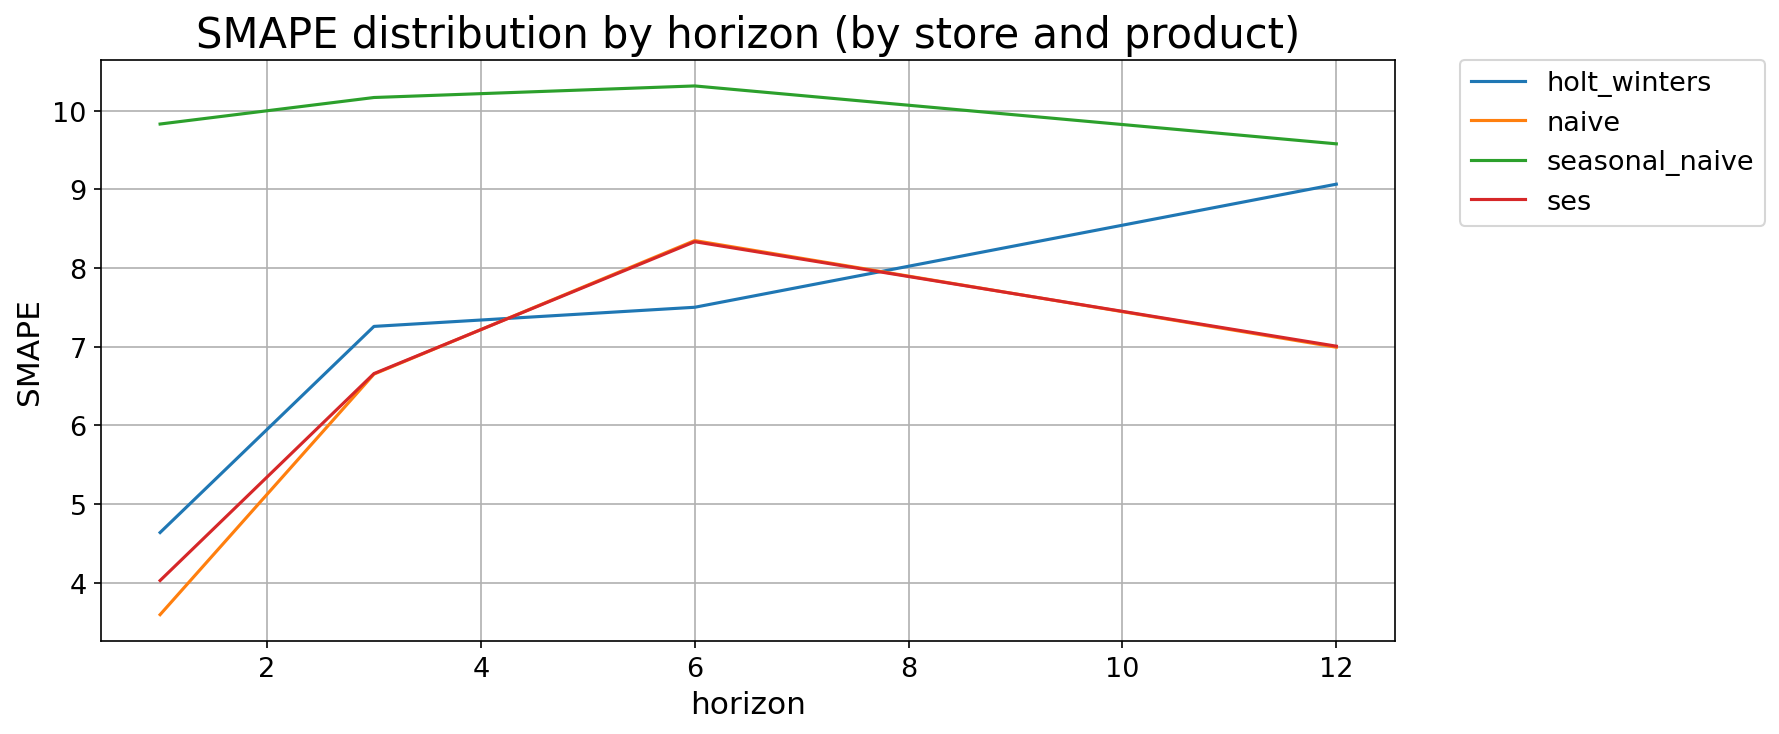

In [56]:
# plt.style.use('default')
plt.figure(figsize=(12,5))
sns.lineplot(summary_stores_products, x = 'horizon', y = 'SMAPE', hue='model')
title = 'SMAPE distribution by horizon (by store and product)'
plt.title(title)
plt.grid()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.savefig('../plots/'+title+'.png')
plt.show()

In [71]:
# Добавим идентификатор уровня агрегации
summary_total['agg_level'] = 'Total'
summary_stores['agg_level'] = 'By Stores'
summary_products['agg_level'] = 'By Products'
summary_stores_products['agg_level'] = 'By Store & Product'

# Объединяем
best_models = pd.concat([
    summary_total.sort_values('SMAPE').groupby('horizon').head(1),
    summary_stores.sort_values('SMAPE').groupby('horizon').head(1),
    summary_products.sort_values('SMAPE').groupby('horizon').head(1),
    summary_stores_products.sort_values('SMAPE').groupby('horizon').head(1)
])

# Сортируем для наглядности
best_models = best_models.sort_values(['horizon', 'agg_level']).reset_index(drop=True)

# Форматируем SMAPE
best_models['SMAPE'] = best_models['SMAPE'].map(lambda x: f"{x:.2f}")

# Выводим
print(best_models.sort_values(['agg_level', 'horizon']).reset_index(drop=True).to_csv())
# Или в Jupyter: display(best_models)

,model,horizon,MAE,RMSE,MAPE,SMAPE,agg_level
0,holt_winters,1,389.5319700772254,389.5319700772254,0.034053031076609404,3.46,By Products
1,ses,3,909.4296529838265,992.1606169298525,0.05502028907161312,5.18,By Products
2,holt_winters,6,890.9299177832883,1026.6990502100916,0.06592690942780939,6.20,By Products
3,naive,12,875.6360606060606,1144.2753503846727,0.057941770097985755,5.91,By Products
4,naive,1,132.28295454545457,132.28295454545457,0.03501320312156204,3.59,By Store & Product
5,naive,3,269.71219696969706,297.66213519353516,0.07009483760565596,6.65,By Store & Product
6,holt_winters,6,278.77438524193855,329.4124723277254,0.08074365835366527,7.50,By Store & Product
7,naive,12,260.9798106060606,339.0628102296386,0.06955923532746107,6.99,By Store & Product
8,naive,1,896.9875000000002,896.9875000000002,0.01866549966388415,1.86,By Stores
9,holt_winters,3,1496.4017145505522,1688.4025768191048,0.027751900328803886,2.72,By Stores
10,seasonal_naive,6,2593.1816666666664,2778.3235282059695,0.0

# Results

## 📊 Вывод по результатам сравнения моделей прогнозирования

В рамках эксперимента было проведено сравнение классических моделей прогнозирования временных рядов (naive, seasonal naive, SES, Holt-Winters) по метрике MAPE на различных горизонтах прогнозирования.

### 🔍 Общие закономерности

1. **Ошибка прогнозирования увеличивается с ростом горизонта**
   Для всех моделей наблюдается рост MAPE при увеличении горизонта прогнозирования (особенно до 6 месяцев), что соответствует теоретическим ожиданиям: чем дальше горизонт, тем выше неопределённость.

2. **Holt-Winters показывает наиболее стабильные результаты**
   Модель Holt-Winters демонстрирует:

   * наименьший рост ошибки
   * устойчивость на длинных горизонтах (6–12)

   Особенно это заметно:

   * на уровне продуктов
   * на агрегированных данных (Total Sales)

3. **Seasonal Naive работает хуже ожиданий**
   Несмотря на наличие сезонности в данных, seasonal naive:

   * часто проигрывает Holt-Winters
   * демонстрирует высокую и слабо снижающуюся ошибку

   Это указывает на то, что **простое копирование сезонного паттерна недостаточно**.


### 📦 Разрез по уровням агрегации

#### 1. По продуктам

* Holt-Winters и SES показывают сопоставимые результаты
* Naive и SES резко ухудшаются на горизонте 6
* Seasonal naive остаётся стабильной, но на более высоком уровне ошибки

👉 Вывод: на уровне продуктов важна модель, учитывающая тренд и сезонность

#### 2. По продуктам и магазинам

* Ошибки значительно выше (до ~0.10 MAPE)
* Holt-Winters становится менее стабильной
* Seasonal naive — худшая модель

👉 Вывод:
при увеличении детализации (granularity) задача становится сложнее из-за шума и разреженности данных

#### 3. По магазинам

* Общий уровень ошибки ниже
* Holt-Winters снова показывает лучшие результаты
* SES нестабилен на средних горизонтах

👉 Вывод:
агрегация по магазинам снижает шум и улучшает качество прогноза

#### 4. Общие продажи (Total Sales)

* Все модели показывают наименьшие ошибки
* Holt-Winters — лучший на всех горизонтах
* SES сильно переобучается на горизонте 6

👉 Вывод:
чем выше уровень агрегации, тем легче задача прогнозирования

---

### 🧠 Ключевые инсайты

* 📉 **Гранулярность напрямую влияет на качество прогноза**
  Чем более детализированы данные, тем выше ошибка

* 📈 **Модели с учётом структуры ряда (trend + seasonality) выигрывают**
  Holt-Winters consistently outperform baseline models

* ⚠️ **Простые модели (naive, seasonal naive) подходят только как baseline**

---

### 🚀 Итог

На основании проведённого анализа можно сделать вывод, что:

> **модель Holt-Winters является наиболее предпочтительной среди рассмотренных для задачи прогнозирования продаж**, так как обеспечивает наилучший баланс между точностью и стабильностью на различных горизонтах и уровнях агрегации данных.
